In [1]:
import geopandas as gpd

In [2]:
wards = gpd.read_file('./climate_change_data/wards.geojson')

<Axes: >

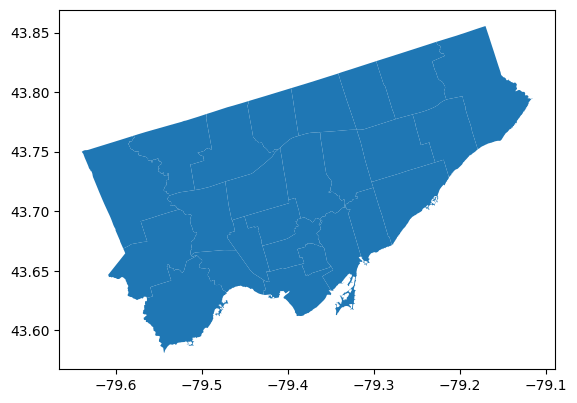

In [3]:
wards.plot()

<Axes: >

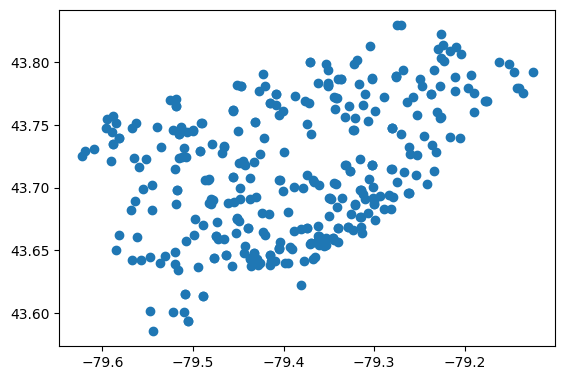

In [4]:
heat_relief_network = gpd.read_file('./climate_change_data/heat_relief_network.geojson')
heat_relief_network.plot()

In [5]:
treed = gpd.read_file('./climate_change_data/treed_area/TOPO_TREED_AREA_WGS84.shp')

<Axes: >

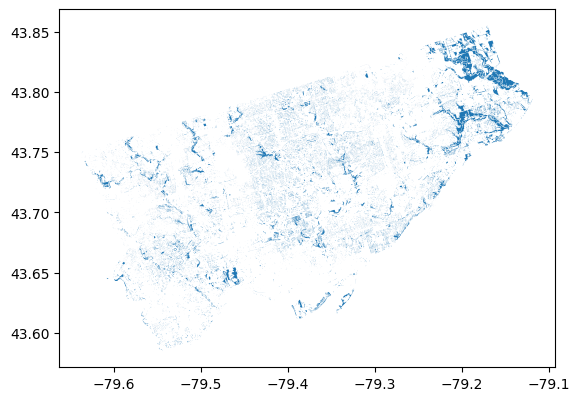

In [6]:
treed.plot()

In [15]:
print(wards.columns)
wards_clean = wards[['AREA_ID', 'AREA_NAME', 'geometry']]
# print(heat_relief_network.crs)
# print(treed.crs)

Index(['_id', 'AREA_ID', 'DATE_EFFECTIVE', 'DATE_EXPIRY', 'AREA_ATTR_ID',
       'AREA_TYPE_ID', 'PARENT_AREA_ID', 'AREA_TYPE', 'AREA_CLASS_ID',
       'AREA_CLASS', 'AREA_SHORT_CODE', 'AREA_LONG_CODE', 'AREA_NAME',
       'AREA_DESC', 'FEATURE_CODE', 'FEATURE_CODE_DESC', 'TRANS_ID_CREATE',
       'TRANS_ID_EXPIRE', 'OBJECTID', 'geometry'],
      dtype='object')


In [19]:
print(heat_relief_network.columns)
heat_clean = heat_relief_network[['locationTypeDesc', 'locationName', 'address', 'phone', 'url', 'geometry']]

Index(['_id', 'locationId', 'locationTypeCode', 'locationTypeDesc',
       'locationCode', 'locationDesc', 'locationName', 'address', 'phone',
       'url', 'imageUrl', 'monOpen', 'monClose', 'tueOpen', 'tueClose',
       'wedOpen', 'wedClose', 'thuOpen', 'thuClose', 'friOpen', 'friClose',
       'satOpen', 'satClose', 'sunOpen', 'sunClose', 'amenities', 'notes',
       'eligibility', 'geometry'],
      dtype='object')


In [21]:
treed = treed[['objectid', 'elevation', 'geometry']]

In [33]:
joined = gpd.sjoin(heat_clean, wards_clean, how = 'left', predicate='within')


In [34]:
print(joined.head(5))

  locationTypeDesc                            locationName  \
0      Indoor Pool             Birchmount Community Centre   
1      Indoor Pool           Gordon A. Brown Middle School   
2      Indoor Pool         Fairmount Park Community Centre   
3      Indoor Pool  Lester B. Pearson Collegiate Institute   
4      Indoor Pool          West Hill Collegiate Institute   

                 address         phone  \
0     93 Birchmount  Rd   416-396-4311   
1   2800 St. Clair  Ave   416-392-6368   
2      1757 Gerrard  St   416-392-7060   
3      150 Tapscott  Rd   416-396-4010   
4  350 Morningside  Ave   416-396-4008   

                                                 url  \
0  https://www.toronto.ca/data/parks/prd/faciliti...   
1  https://www.toronto.ca/data/parks/prd/faciliti...   
2  https://www.toronto.ca/data/parks/prd/faciliti...   
3  https://www.toronto.ca/data/parks/prd/faciliti...   
4  https://www.toronto.ca/data/parks/prd/faciliti...   

                            geometry 

<Axes: >

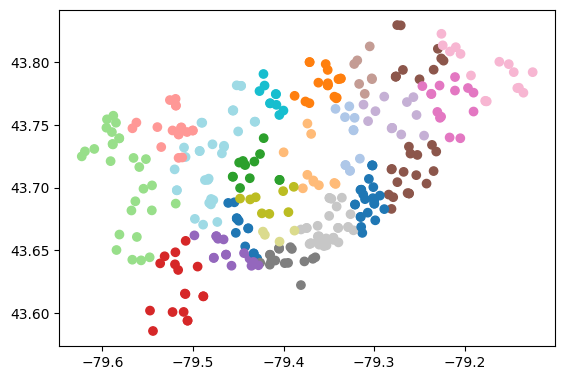

In [36]:
joined.plot(column = 'AREA_NAME', cmap = 'tab20')

In [ ]:
groups = joined.groupby('AREA_NAME').size()
wards['num_heat_lands'] = wards['AREA_NAME'].map(groups)

AREA_NAME
Beaches-East York           24
Davenport                   13
Don Valley East             11
Don Valley North            18
Don Valley West             10
Eglinton-Lawrence           13
Etobicoke Centre             9
Etobicoke North             19
Etobicoke-Lakeshore         17
Humber River-Black Creek    18
Parkdale-High Park          16
Scarborough Centre          12
Scarborough North           11
Scarborough Southwest       18
Scarborough-Agincourt        7
Scarborough-Guildwood       14
Scarborough-Rouge Park      16
Spadina-Fort York           17
Toronto Centre              15
Toronto-Danforth            17
Toronto-St. Paul's           8
University-Rosedale          4
Willowdale                  10
York Centre                 19
York South-Weston           13
dtype: int64


<Axes: >

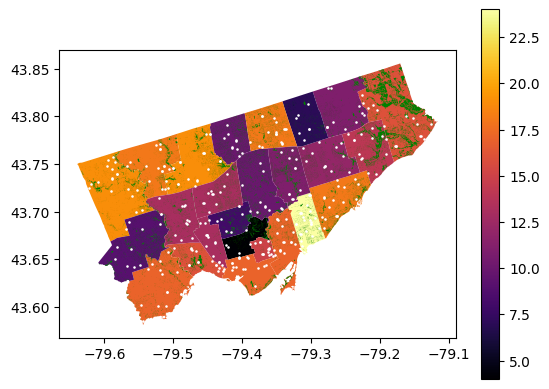

In [52]:
x = wards.plot(column='num_heat_lands', cmap='inferno', legend = True)
treed.plot(ax=x, color = 'green')
heat_clean.plot(ax=x, markersize=0.7, color='white')


In [53]:
wards_clean.to_file('wards_updated.geojson', driver = 'GeoJSON')
heat_clean.to_file('heat_locations_updated.geojson', driver = 'GeoJSON')